In [1]:
from NaNoPy.decorators import loop
from NaNoPy import Canvas, Writer, Color

import math
import numpy as np

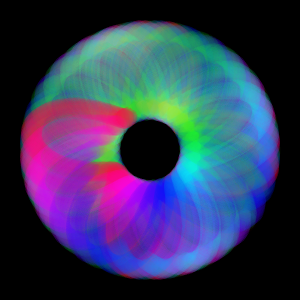

In [2]:
xSize = 300
ySize = 300

@loop(600, xSize, ySize, additive = True)
def rainbow_blob(screen: Canvas, pen: Writer, i: int):
	import colorsys
	theta = i * .01

	for j in range(20):
		phase = j * 2 * math.pi / 20
		r = 40 * (2 + math.sin(i * .04 + phase))
		(r_, g, b) = colorsys.hls_to_rgb((j / 20), .5, 1)

		pen.draw_circle(xSize // 2 + r * math.sin(theta + phase),
				ySize // 2 + r * math.cos(theta + phase),
				10,
				Color.custom(r=int(r_ * 255), g=int(g * 255), b=int(b * 255), a=j),
				True)
	screen.pause(16)


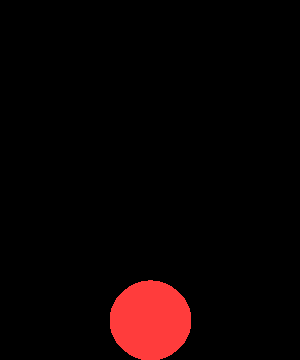

In [3]:
xSize = 300
ySize = 360

v_ball = 0
y_ball = 200

color_ball = Color.custom(r=255, g=60, b=60)

@loop(600, xSize, ySize)
def ball_down(screen: Canvas, pen: Writer, i: int):
	global v_ball, y_ball

	v_ball -= .98 # Gravitational acceleration

	y_ball += v_ball


	pen.draw_circle(xSize // 2, y_ball, 40, color_ball, True)
	screen.pause(16)
     
	if y_ball < 40:
		y_ball = 40
		v_ball = -v_ball * .8
		if abs(v_ball) < 1:
			return False # End the animation


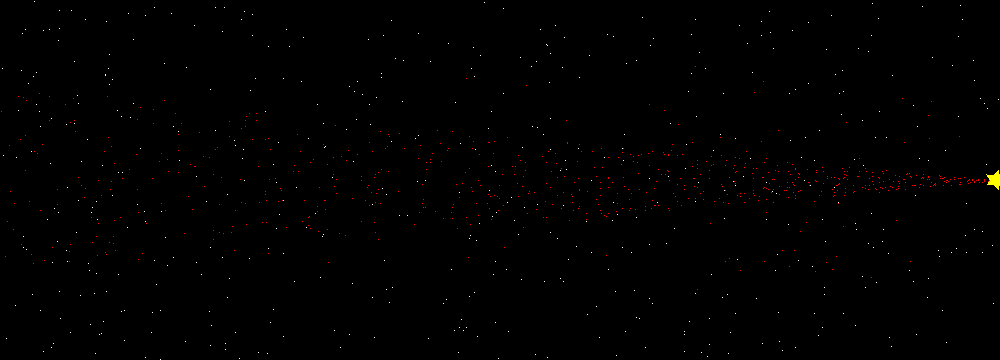

In [4]:
xSize = 1000
ySize = 360

y = ySize / 2
stars = []
particles = []
rng = np.random.default_rng(1337)

for _ in range(500):
    stars.append(
        (
            int(rng.integers(0, xSize)),
            int(rng.integers(0, ySize)),
        )
    )


@loop(600, xSize, ySize)
def star_test(screen: Canvas, pen: Writer, i: int):
    global particles

    x = (i * 5) % xSize

    # Draw background stars
    for star in stars:
        pen.drawPixel(star[0], star[1], Color.white)

    # Add new particles at the star's position
    for _ in range(5):  # Add 5 particles each frame
        particles.append(
            [
                x,
                y,
                rng.uniform(-1.0, 0.0),
                rng.uniform(-0.5, 0.5),
                int(rng.integers(5, 301)),
            ]
        )  # [x, y, x_velocity, y_velocity, lifetime]

    # Update and draw particles
    j = 0
    while j < len(particles):
        particle = particles[j]
        # Update particle position
        particle[0] += particle[2]  # Update x position
        particle[1] += particle[3]  # Update y position
        particle[4] -= 1  # Decrease lifetime

        # Draw the particle
        pen.drawPixel(int(particle[0]), int(particle[1]), Color.red)

        # Remove particles that have expired
        if particle[4] <= 0:
            particles.pop(j)
        else:
            j += 1

    # Draw the star
    pen.drawStar(x, y, 10, 5, Color.yellow, True)

# MP4 Export Examples

You can export any animation as an MP4 file by adding the `record_mp4` parameter to the `@loop` decorator.
The animation will be displayed in the notebook AND saved to disk as a video file.

**Note**: Requires ffmpeg to be installed. Only captures frames when recording is explicitly enabled (memory-efficient).

In [ ]:
# Example 1: Simple animated circle with MP4 export
xSize = 400
ySize = 400

@loop(120, xSize, ySize, record_mp4="animated_circle.mp4", fps=30)
def animated_circle(screen: Canvas, pen: Writer, i: int):
    x = xSize // 2 + 100 * math.sin(i * 0.05)
    y = ySize // 2 + 100 * math.cos(i * 0.05)
    pen.draw_circle(int(x), int(y), 30, Color.cyan, filled=True)


In [ ]:
# Example 2: Additive rendering with MP4 export
xSize = 350
ySize = 350

@loop(200, xSize, ySize, additive=True, record_mp4="additive_spiral.mp4", fps=30)
def spiral_trail(screen: Canvas, pen: Writer, i: int):
    import colorsys
    angle = i * 0.1
    radius = 50 + i * 0.5
    x = xSize // 2 + radius * math.cos(angle)
    y = ySize // 2 + radius * math.sin(angle)
    
    hue = (i / 200) % 1.0
    r, g, b = colorsys.hsv_to_rgb(hue, 0.8, 1.0)
    color = Color.custom(r=int(r*255), g=int(g*255), b=int(b*255))
    
    pen.draw_circle(int(x), int(y), 8, color, filled=True)
